In [1]:
import pandas as pd
df = pd.read_csv("train_and_test2.csv")
# dropping OHE columns and passenger id
# new OHE will be made 
cols_to_drop = [c for c in df.columns if c.lower().startswith("zero")] + ["Passengerid"]
df = df.drop(columns=cols_to_drop, errors="ignore")
            
df = df.rename(columns={"sibsp":"SibSp", "2urvived":"Survived"})

keep = ["Survived","Pclass","Sex","Age","SibSp","Parch","Fare","Embarked"]
missing = [c for c in keep if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

df = df[keep].copy()
print("Nulls per col:\n", df.isna().sum())
df.head()


Nulls per col:
 Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,2.0
1,1,1,1,38.0,1,0,71.2833,0.0
2,1,3,1,26.0,0,0,7.9250,2.0
3,1,1,1,35.0,1,0,53.1000,2.0
4,0,3,0,35.0,0,0,8.0500,2.0


In [2]:
print(df["SibSp"].unique())
print(df["Parch"].unique())

[1 0 3 4 2 5 8]
[0 1 2 5 3 4 6 9]


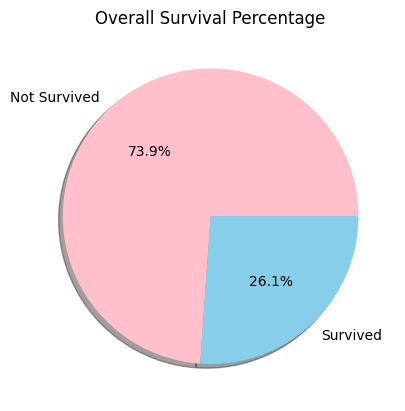

In [8]:
df["Survived"].value_counts().plot.pie(autopct="%1.1f%%", labels=["Not Survived", "Survived"], colors=["pink", "skyblue"],shadow=True)
plt.title("Overall Survival Percentage")
plt.ylabel("") 
plt.show()

/tmp/ipykernel_1243/355242590.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax=sns.barplot(x=df["Pclass"], y=df["Survived"]*100,hue=df['Sex'],ci=None,palette="dark:#5A9_r")


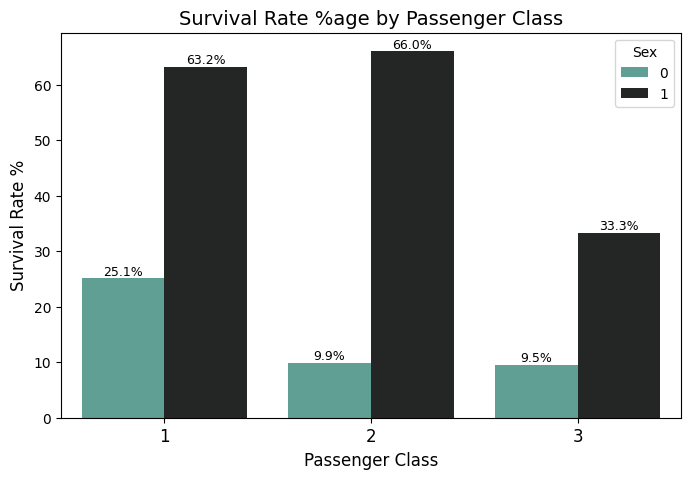

In [9]:
# Bar Plot: Survival Rate by Class
plt.figure(figsize=(8, 5))
ax=sns.barplot(x=df["Pclass"], y=df["Survived"]*100,hue=df['Sex'],ci=None,palette="dark:#5A9_r")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9)
plt.xlabel("Passenger Class",fontsize=12)
plt.ylabel("Survival Rate %",fontsize=12)
plt.title("Survival Rate %age by Passenger Class",fontsize=14)
plt.xticks(fontsize=12)
plt.show()

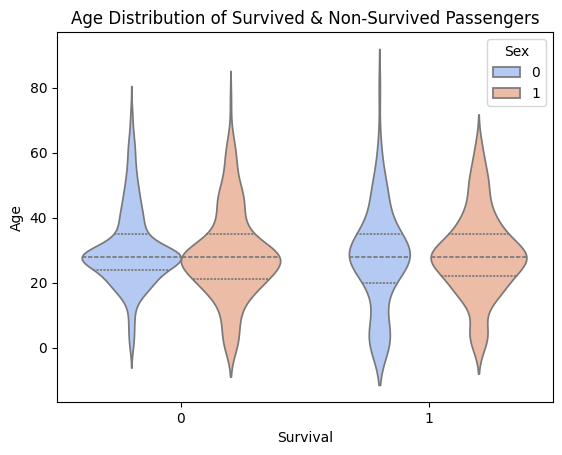

In [10]:
# Violin Plot: Age Distribution among Survived & Not Survived
sns.violinplot(x="Survived", y="Age", hue="Sex",data=df, palette="coolwarm", inner="quartile")
plt.title("Age Distribution of Survived & Non-Survived Passengers")
plt.xlabel('Survival')
plt.show()

/home/samuel/tf_gpu/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 64.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/samuel/tf_gpu/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 28.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/samuel/tf_gpu/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 72.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/samuel/tf_gpu/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 41.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


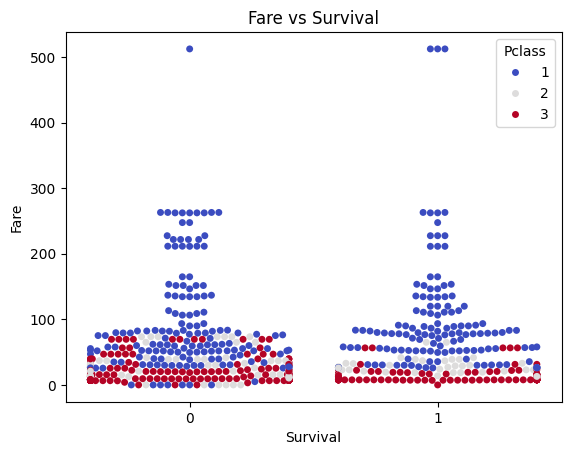

In [11]:
# Swarm Plot: Fare vs Survival
sns.swarmplot(x="Survived", y="Fare",hue="Pclass",data=df, palette="coolwarm")
plt.title("Fare vs Survival")
plt.xlabel('Survival')
plt.show()

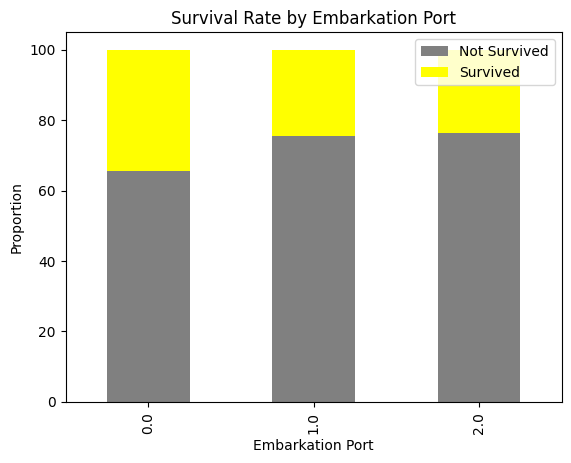

In [12]:
# Stacked Bar Chart: Survival by Embarkation
embarked_survival = df.groupby("Embarked")["Survived"].value_counts(normalize=True).unstack()*100
embarked_survival.plot(kind="bar", stacked=True, color=["grey", "yellow"])
plt.xlabel("Embarkation Port")
plt.ylabel("Proportion")
plt.title("Survival Rate by Embarkation Port")
plt.legend(["Not Survived", "Survived"])
plt.show()

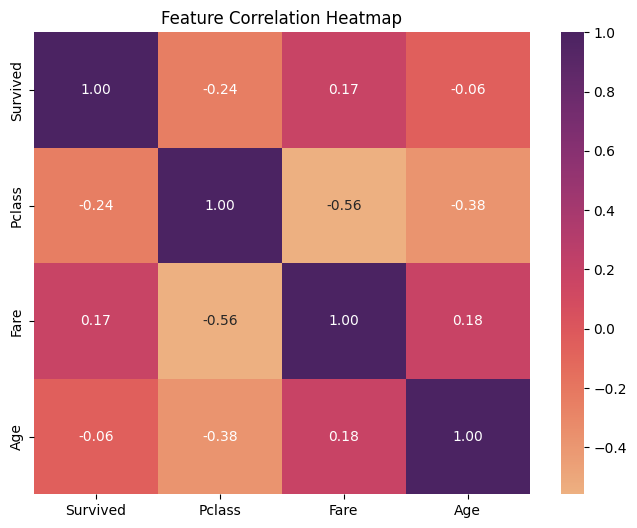

In [13]:
# Heatmap: Correlation of Survival with Other Features
plt.figure(figsize=(8,6))
sns.heatmap(df[["Survived", "Pclass", "Fare","Age"]].corr(), annot=True, cmap="flare", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# split training(x) and target(y) variables
X = df.drop(columns=["Survived"])
y = df["Survived"].astype(int)

OHE_PCLASS = True  # you can set to False to keep Pclass as 1/2/3 numeric

num_cols = ["Age","SibSp","Parch","Fare"]
cat_cols = ["Embarked", "Sex"] + (["Pclass"] if OHE_PCLASS else [])


num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    # apply OHE to categorial data
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
# pass in pipelines to their columns
preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
], remainder=("passthrough" if not OHE_PCLASS else "drop"))

# full model pipeline chains preprocessing and model
# main things to tweak is regularization param C and solver param
clf = Pipeline([
    ("prep", preprocess),
    ("logreg", LogisticRegression(class_weight="balanced", max_iter=1000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

clf.fit(X_train, y_train)
print("Model trained.")


Model trained.


In [4]:
y_pred  = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("\nReport:\n", classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.6985
ROC AUC: 0.7606

Report:
               precision    recall  f1-score   support

           0     0.8662    0.7010    0.7749       194
           1     0.4476    0.6912    0.5434        68

    accuracy                         0.6985       262
   macro avg     0.6569    0.6961    0.6591       262
weighted avg     0.7576    0.6985    0.7148       262

Confusion matrix:
 [[136  58]
 [ 21  47]]


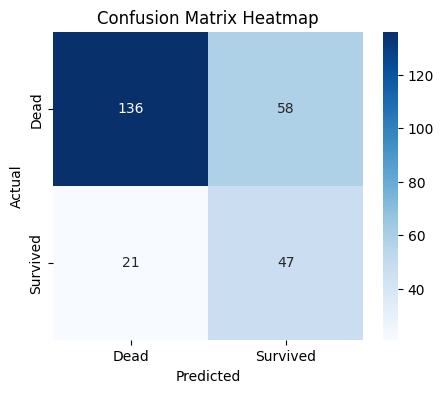

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Dead","Survived"], yticklabels=["Dead","Survived"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title("Confusion Matrix Heatmap")
plt.show()


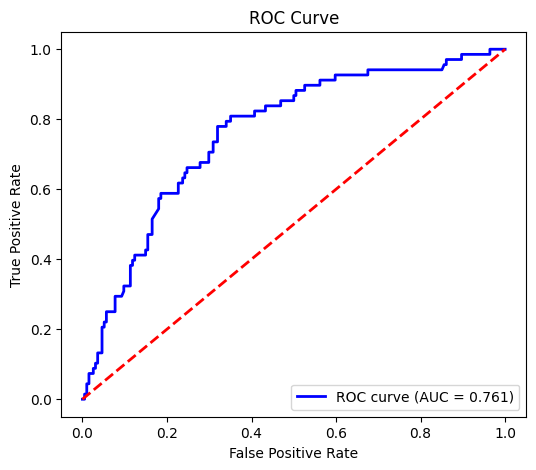

In [6]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='red', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()


In [7]:
import numpy as np
import pandas as pd

# after training clf
feature_names = (clf.named_steps['prep'].named_transformers_['num']
                 .get_feature_names_out(num_cols).tolist() +
                 clf.named_steps['prep'].named_transformers_['cat']
                 .get_feature_names_out(cat_cols).tolist())

coefs = clf.named_steps['logreg'].coef_[0]
importance = pd.DataFrame({'feature': feature_names, 'coef': coefs})
importance['abs_coef'] = importance['coef'].abs()
importance = importance.sort_values(by='abs_coef', ascending=False)
print(importance)


         feature      coef  abs_coef
8        Sex_1.0  1.015417  1.015417
7        Sex_0.0 -0.898142  0.898142
9     Pclass_1.0  0.833331  0.833331
11    Pclass_3.0 -0.796709  0.796709
0            Age -0.415823  0.415823
1          SibSp -0.170488  0.170488
4   Embarked_0.0  0.132159  0.132159
10    Pclass_2.0  0.080653  0.080653
6   Embarked_2.0 -0.038473  0.038473
3           Fare -0.024119  0.024119
5   Embarked_1.0  0.023589  0.023589
2          Parch -0.022313  0.022313


Variable	Definition	Key
survival	Survival	0 = No, 1 = Yes
pclass	Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd
sex	Sex	
Age	Age in years	
sibsp	# of siblings / spouses aboard the Titanic	
parch	# of parents / children aboard the Titanic	
ticket	Ticket number	
fare	Passenger fare	
cabin	Cabin number	
embarked	Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton